In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

## Load dirs

In [7]:
nback_dir = Path(r"..\..\data\2-back_dual\beh+sub\2-back_dual test")
wcst_before_dir = Path(r"..\..\data\2-back_dual\beh+sub\wcst_before test")
wcst_after_dir  = Path(r"..\..\data\2-back_dual\beh+sub\wcst_after test")

nback_files = list(nback_dir.glob("*.csv"))
wcst_before_files = list(wcst_before_dir.glob("*.csv"))
wcst_after_files  = list(wcst_after_dir.glob("*.csv"))

print(len(nback_files), "2-back dual files")
print(len(wcst_before_files), "WCST before files")
print(len(wcst_after_files), "WCST after files")

1 2-back dual files
1 WCST before files
1 WCST after files


In [28]:
participants = {}

file_groups = [
    ("before", wcst_before_files),
    ("after", wcst_after_files),
    ("nback", nback_files),
]

for key, files in file_groups:
    for f in files:
        match = re.match(r"^\s*(\d+)\s*[-_ ]", f.name)
        if not match:
            continue

        pid = match.group(1)

        if pid not in participants:
            participants[pid] = {
                "before": None,
                "after": None,
                "nback": None
            }

        participants[pid][key] = f

In [29]:
for pid, files in sorted(participants.items(), key=lambda x: int(x[0])):
    print(f"\n--- Participant {pid} ---")

    print(f"BEFORE : {files['before']}")
    print(f"NBACK  : {files['nback']}")
    print(f"AFTER  : {files['after']}")


--- Participant 1 ---
BEFORE : ..\..\data\2-back_dual\beh+sub\wcst_before test\1 - DUAL_Wisconsin Card Sorting Task_2026-05-05_11h12.45.628.csv
NBACK  : ..\..\data\2-back_dual\beh+sub\2-back_dual test\1 - DUAL_untitled_2026-05-05_11h17.28.796.csv
AFTER  : ..\..\data\2-back_dual\beh+sub\wcst_after test\1 - DUAL_Wisconsin Card Sorting Task_2026-05-05_11h45.18.218.csv


In [30]:
participant_data = {}

for pid, files in participants.items():
    if None in files.values():
        print(f"Skipping participant {pid} (missing data)")
        continue

    participant_data[pid] = {
        "wcst_before": pd.read_csv(files["before"]),
        "wcst_after": pd.read_csv(files["after"]),
        "nback": pd.read_csv(files["nback"])
    }

## WCST Before X After

In [31]:
def summarize_wcst_run(df):
    trials = df.copy()
    trials["correct_num"] = pd.to_numeric(trials["correct"], errors="coerce")
    trials = trials[trials["correct_num"].isin([0, 1])].copy()

    if trials.empty:
        return {
            "n_trials": 0,
            "accuracy": np.nan,
            "errors": np.nan,
            "mean_response_time": np.nan,
            "mean_trial_time": np.nan,
        }

    out = {
        "n_trials": len(trials),
        "accuracy": trials["correct_num"].mean(),
        "errors": (1 - trials["correct_num"]).sum(),
        "mean_response_time": np.nan,
        "mean_trial_time": np.nan,
    }

    # Mouse-click latency proxy: from fixation offset to trial end on click
    if {"Trials.stopped", "fixation.stopped"}.issubset(trials.columns):
        trial_stop = pd.to_numeric(trials["Trials.stopped"], errors="coerce")
        fix_stop = pd.to_numeric(trials["fixation.stopped"], errors="coerce")
        out["mean_response_time"] = (trial_stop - fix_stop).mean()
    elif "response.started" in trials.columns:
        # Fallback when fixation timing is unavailable
        rt = pd.to_numeric(trials["response.started"], errors="coerce")
        out["mean_response_time"] = rt.mean()

    # Longer duration including fixation + response + feedback/transition
    if {"Trials.stopped", "trial_card.started"}.issubset(trials.columns):
        stop_t = pd.to_numeric(trials["Trials.stopped"], errors="coerce")
        start_t = pd.to_numeric(trials["trial_card.started"], errors="coerce")
        out["mean_trial_time"] = (stop_t - start_t).mean()

    return out


rows = []
for pid, data in sorted(participant_data.items(), key=lambda x: int(x[0])):
    before = summarize_wcst_run(data["wcst_before"])
    after = summarize_wcst_run(data["wcst_after"])

    rows.append({
        "participant": int(pid),
        "n_trials_before": before["n_trials"],
        "n_trials_after": after["n_trials"],
        "acc_before": before["accuracy"],
        "acc_after": after["accuracy"],
        "errors_before": before["errors"],
        "errors_after": after["errors"],
        "response_time_before": before["mean_response_time"],
        "response_time_after": after["mean_response_time"],
        "trial_time_before": before["mean_trial_time"],
        "trial_time_after": after["mean_trial_time"],
    })

wcst_paired = pd.DataFrame(rows).sort_values("participant").reset_index(drop=True)
wcst_paired

,participant,n_trials_before,n_trials_after,acc_before,acc_after,errors_before,errors_after,response_time_before,response_time_after,trial_time_before,trial_time_after
0,1,42,42,0.785714,0.785714,9.0,9.0,2.724645,1.657458,2.739324,1.66814


In [32]:
wcst_paired["delta_acc"] = wcst_paired["acc_after"] - wcst_paired["acc_before"]
wcst_paired["delta_errors"] = wcst_paired["errors_after"] - wcst_paired["errors_before"]
wcst_paired["delta_response_time"] = wcst_paired["response_time_after"] - wcst_paired["response_time_before"]
wcst_paired["delta_trial_time"] = wcst_paired["trial_time_after"] - wcst_paired["trial_time_before"]

display(wcst_paired.round(3))

summary = pd.DataFrame({
    "before_mean": [
        wcst_paired["acc_before"].mean(),
        wcst_paired["errors_before"].mean(),
        wcst_paired["response_time_before"].mean(),
        wcst_paired["trial_time_before"].mean(),
    ],
    "after_mean": [
        wcst_paired["acc_after"].mean(),
        wcst_paired["errors_after"].mean(),
        wcst_paired["response_time_after"].mean(),
        wcst_paired["trial_time_after"].mean(),
    ],
    "mean_change_after_minus_before": [
        wcst_paired["delta_acc"].mean(),
        wcst_paired["delta_errors"].mean(),
        wcst_paired["delta_response_time"].mean(),
        wcst_paired["delta_trial_time"].mean(),
    ],
}, index=["accuracy", "errors", "response_time_sec", "trial_time_sec"])

display(summary.round(4))

,participant,n_trials_before,n_trials_after,acc_before,acc_after,errors_before,errors_after,response_time_before,response_time_after,trial_time_before,trial_time_after,delta_acc,delta_errors,delta_response_time,delta_trial_time
0,1,42,42,0.786,0.786,9.0,9.0,2.725,1.657,2.739,1.668,0.0,0.0,-1.067,-1.071


,before_mean,after_mean,mean_change_after_minus_before
accuracy,0.7857,0.7857,0.0000
errors,9.0000,9.0000,0.0000
response_time_sec,2.7246,1.6575,-1.0672
trial_time_sec,2.7393,1.6681,-1.0712


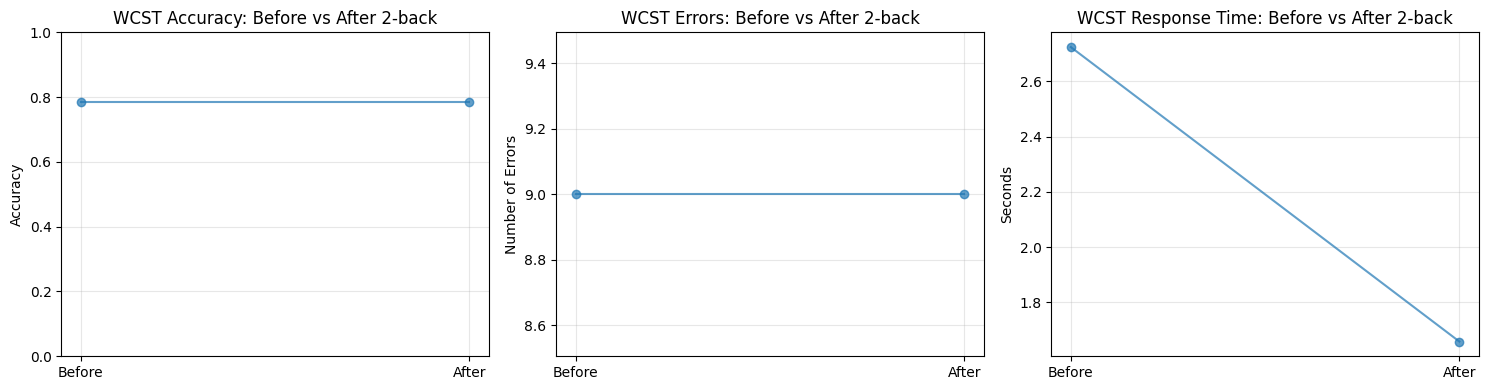

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for _, r in wcst_paired.iterrows():
    axes[0].plot(["Before", "After"], [r["acc_before"], r["acc_after"]], marker="o", alpha=0.7)
axes[0].set_title("WCST Accuracy: Before vs After 2-back")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

for _, r in wcst_paired.iterrows():
    axes[1].plot(["Before", "After"], [r["errors_before"], r["errors_after"]], marker="o", alpha=0.7)
axes[1].set_title("WCST Errors: Before vs After 2-back")
axes[1].set_ylabel("Number of Errors")
axes[1].grid(alpha=0.3)

for _, r in wcst_paired.iterrows():
    axes[2].plot(["Before", "After"], [r["response_time_before"], r["response_time_after"]], marker="o", alpha=0.7)
axes[2].set_title("WCST Response Time: Before vs After 2-back")
axes[2].set_ylabel("Seconds")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

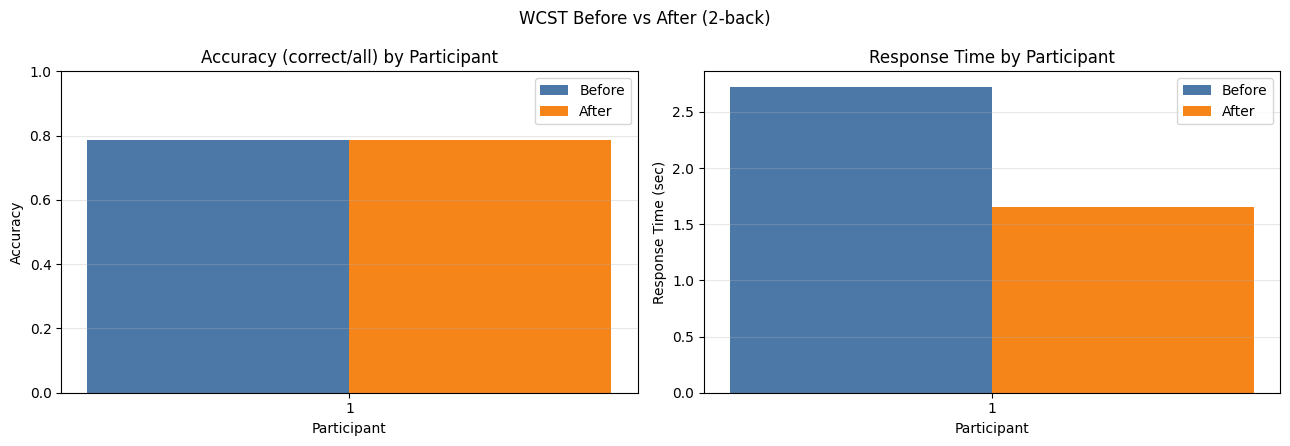

In [34]:
# Participant-wise bars in one figure (accuracy + click latency)
x = np.arange(len(wcst_paired))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(x - width / 2, wcst_paired["acc_before"], width=width, label="Before", color="#4C78A8")
axes[0].bar(x + width / 2, wcst_paired["acc_after"], width=width, label="After", color="#F58518")
axes[0].set_xticks(x, wcst_paired["participant"].astype(str))
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Participant")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy (correct/all) by Participant")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - width / 2, wcst_paired["response_time_before"], width=width, label="Before", color="#4C78A8")
axes[1].bar(x + width / 2, wcst_paired["response_time_after"], width=width, label="After", color="#F58518")
axes[1].set_xticks(x, wcst_paired["participant"].astype(str))
axes[1].set_xlabel("Participant")
axes[1].set_ylabel("Response Time (sec)")
axes[1].set_title("Response Time by Participant")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("WCST Before vs After (2-back)")
plt.tight_layout()
plt.show()

## Wilcoxon paired test WCST Before X After

In [35]:
from scipy.stats import wilcoxon, ttest_rel


def run_paired_test(df, before_col, after_col, metric_name):
    pair = df[[before_col, after_col]].dropna()
    before_vals = pair[before_col]
    after_vals = pair[after_col]
    diff = after_vals - before_vals

    wilcoxon_stat = np.nan
    wilcoxon_p = np.nan
    if not np.allclose(diff.to_numpy(), 0):
        wilcoxon_stat, wilcoxon_p = wilcoxon(before_vals, after_vals)

    t_stat, t_p = ttest_rel(before_vals, after_vals, nan_policy="omit")

    return {
        "metric": metric_name,
        "n_pairs": len(pair),
        "before_mean": before_vals.mean(),
        "after_mean": after_vals.mean(),
        "mean_change_after_minus_before": diff.mean(),
        "wilcoxon_stat": wilcoxon_stat,
        "wilcoxon_p": wilcoxon_p,
        "ttest_p": t_p,
    }


stats_rows = [
    run_paired_test(wcst_paired, "acc_before", "acc_after", "accuracy"),
    run_paired_test(wcst_paired, "errors_before", "errors_after", "errors"),
    run_paired_test(wcst_paired, "response_time_before", "response_time_after", "click_latency_sec"),
    run_paired_test(wcst_paired, "trial_time_before", "trial_time_after", "trial_time_sec"),
]

stats_results = pd.DataFrame(stats_rows)
display(stats_results.round(4))

alpha = 0.05

c:\Users\n.saleem\AppData\Local\miniconda3\envs\eeg\Lib\site-packages\scipy\stats\_stats_py.py:1243: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\n.saleem\AppData\Local\miniconda3\envs\eeg\Lib\site-packages\scipy\stats\_stats_py.py:1243: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\n.saleem\AppData\Local\miniconda3\envs\eeg\Lib\site-packages\scipy\stats\_stats_py.py:1243: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\n.saleem\AppData\Local\miniconda3\envs\eeg\Lib\site-packages\scipy\stats\_stats_py.py:1243: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\n.saleem\AppData\Local\miniconda3\envs\eeg\Lib\site-packages\scipy\stats\_stats_py.py:1

,metric,n_pairs,before_mean,after_mean,mean_change_after_minus_before,wilcoxon_stat,wilcoxon_p,ttest_p
0,accuracy,1,0.7857,0.7857,0.0000,NaN,NaN,NaN
1,errors,1,9.0000,9.0000,0.0000,NaN,NaN,NaN
2,click_latency_sec,1,2.7246,1.6575,-1.0672,0.0,1.0,NaN
3,trial_time_sec,1,2.7393,1.6681,-1.0712,0.0,1.0,NaN


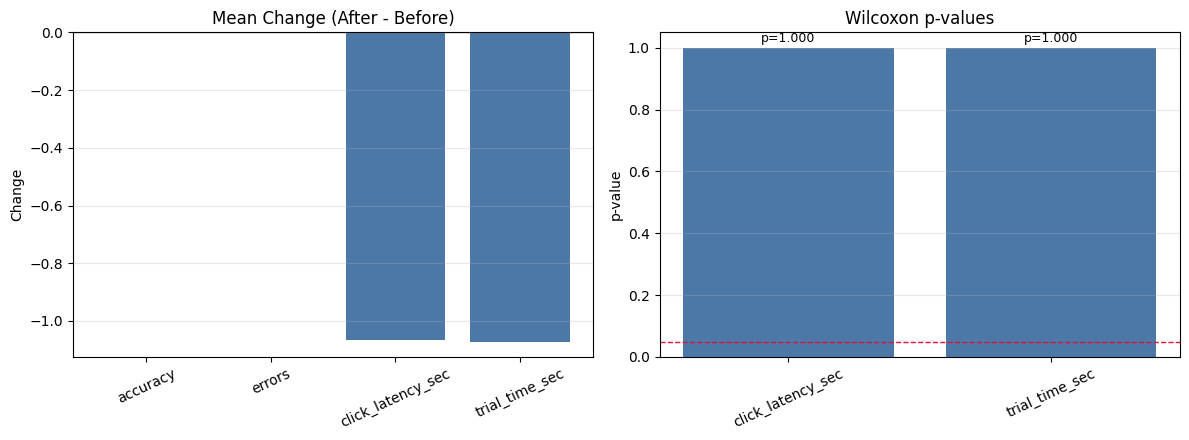

In [36]:
plot_df = stats_results.copy()
plot_df["sig_color"] = np.where(plot_df["wilcoxon_p"] < alpha, "#F58518", "#4C78A8")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(plot_df["metric"], plot_df["mean_change_after_minus_before"], color=plot_df["sig_color"])
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set_title("Mean Change (After - Before)")
axes[0].set_ylabel("Change")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(plot_df["metric"], plot_df["wilcoxon_p"], color=plot_df["sig_color"])
axes[1].axhline(alpha, color="crimson", linestyle="--", linewidth=1)
axes[1].set_title("Wilcoxon p-values")
axes[1].set_ylabel("p-value")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

for i, p in enumerate(plot_df["wilcoxon_p"]):
    axes[1].text(i, p + 0.02, f"p={p:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()